# Model Comparison

This notebook compares the trained ABSA models.

The goal is to show which model performs best and why the final demo should use the deep learning model.

## 1. Models Compared

The project has three methods:

- Rule-based method
- Traditional machine learning method
- Deep learning / DeBERTa method

The rule-based method is an explainable baseline. The saved metric reports are available for Traditional ML and Deep Learning / DeBERTa, so this notebook compares those two trained models.

In [1]:
from pathlib import Path
import json
from statistics import mean

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "backends").exists():
    PROJECT_ROOT = Path.cwd().parents[1]

TRADITIONAL_REPORT = PROJECT_ROOT / "backends" / "traditional_ml" / "training_report.json"
BERT_REPORT = PROJECT_ROOT / "backends" / "deep_learning" / "bert_training_report.json"

traditional_report = json.loads(TRADITIONAL_REPORT.read_text(encoding="utf-8"))
bert_report = json.loads(BERT_REPORT.read_text(encoding="utf-8"))

def print_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        widths = [max(width, len(str(value))) for width, value in zip(widths, row)]
    fmt = "  ".join("{:<" + str(width) + "}" for width in widths)
    print(fmt.format(*headers))
    print(fmt.format(*["-" * width for width in widths]))
    for row in rows:
        print(fmt.format(*row))

print("Loaded reports successfully.")

Loaded reports successfully.


## 2. Overall Comparison

For Traditional ML, the scores are averaged across the four aspects.

For Deep Learning / DeBERTa, the report already has one final test score because it uses review-aspect pairs.

In [2]:
traditional_metrics = traditional_report["metrics"]
traditional_accuracy = mean(item["accuracy"] for item in traditional_metrics.values())
traditional_macro_f1 = mean(item["macro_f1"] for item in traditional_metrics.values())
traditional_weighted_f1 = mean(item["weighted_f1"] for item in traditional_metrics.values())

bert_metrics = bert_report["test_metrics"]

comparison_rows = [
    ["Traditional ML", f"{traditional_accuracy:.4f}", f"{traditional_macro_f1:.4f}", f"{traditional_weighted_f1:.4f}"],
    ["Deep Learning / DeBERTa", f"{bert_metrics['accuracy']:.4f}", f"{bert_metrics['macro_f1']:.4f}", f"{bert_metrics['weighted_f1']:.4f}"],
]

print_table(["Model", "Accuracy", "Macro F1", "Weighted F1"], comparison_rows)

Model                    Accuracy  Macro F1  Weighted F1
-----------------------  --------  --------  -----------
Traditional ML           0.8752    0.5867    0.8560     
Deep Learning / DeBERTa  0.9197    0.8205    0.9206     


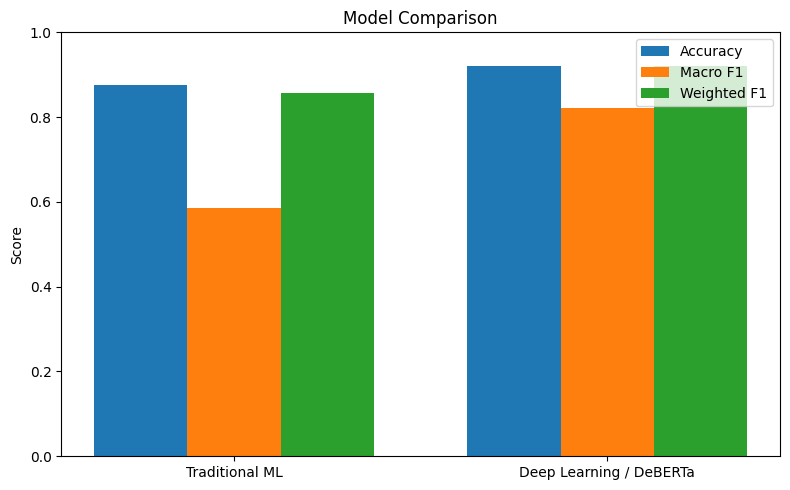

In [3]:
models = [row[0] for row in comparison_rows]
accuracy = [float(row[1]) for row in comparison_rows]
macro_f1 = [float(row[2]) for row in comparison_rows]
weighted_f1 = [float(row[3]) for row in comparison_rows]

x = range(len(models))
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar([i - width for i in x], accuracy, width=width, label="Accuracy")
plt.bar(list(x), macro_f1, width=width, label="Macro F1")
plt.bar([i + width for i in x], weighted_f1, width=width, label="Weighted F1")
plt.xticks(list(x), models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Macro F1 Comparison

Macro F1 is the most important comparison score because the dataset is imbalanced.

A higher macro F1 means the model performs more fairly across Positive, Negative, and Unknown labels.

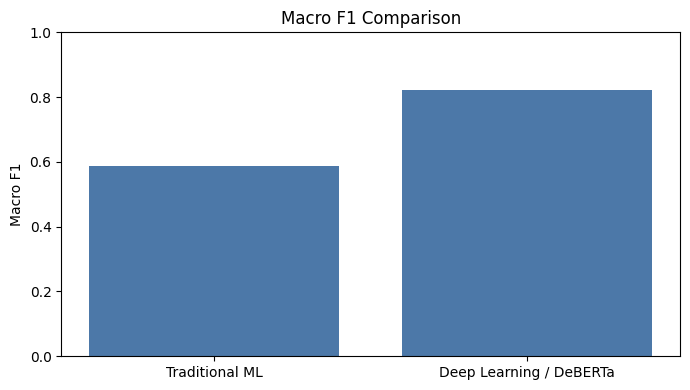

Best model by Macro F1: Deep Learning / DeBERTa (0.8205)


In [4]:
plt.figure(figsize=(7, 4))
plt.bar(models, macro_f1, color="#4C78A8")
plt.ylim(0, 1)
plt.ylabel("Macro F1")
plt.title("Macro F1 Comparison")
plt.tight_layout()
plt.show()

best_index = macro_f1.index(max(macro_f1))
print(f"Best model by Macro F1: {models[best_index]} ({macro_f1[best_index]:.4f})")

## 4. Traditional ML Details

Traditional ML has different performance for each aspect. It gets high accuracy on some aspects, but macro F1 is lower because Positive and Negative labels are harder than Unknown.

In [5]:
traditional_rows = []
for aspect, metrics in traditional_metrics.items():
    traditional_rows.append([
        aspect,
        f"{metrics['accuracy']:.4f}",
        f"{metrics['macro_f1']:.4f}",
        f"{metrics['weighted_f1']:.4f}",
    ])

print_table(["Aspect", "Accuracy", "Macro F1", "Weighted F1"], traditional_rows)

Aspect                         Accuracy  Macro F1  Weighted F1
-----------------------------  --------  --------  -----------
Food                           0.8210    0.6686    0.8105     
Service                        0.8555    0.5748    0.8310     
Price                          0.9294    0.5904    0.9095     
Eating Environment / Ambiance  0.8949    0.5130    0.8729     


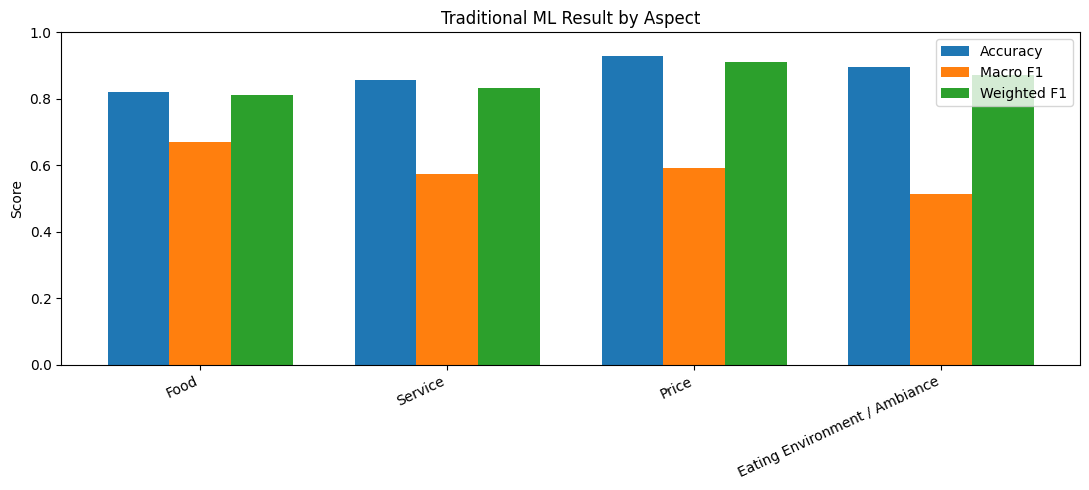

In [6]:
aspects = [row[0] for row in traditional_rows]
trad_accuracy = [float(row[1]) for row in traditional_rows]
trad_macro_f1 = [float(row[2]) for row in traditional_rows]
trad_weighted_f1 = [float(row[3]) for row in traditional_rows]

x = range(len(aspects))
width = 0.25
plt.figure(figsize=(11, 5))
plt.bar([i - width for i in x], trad_accuracy, width=width, label="Accuracy")
plt.bar(list(x), trad_macro_f1, width=width, label="Macro F1")
plt.bar([i + width for i in x], trad_weighted_f1, width=width, label="Weighted F1")
plt.xticks(list(x), aspects, rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Traditional ML Result by Aspect")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Deep Learning Per-label Details

The deep learning model performs best overall. The Unknown label is easiest because it has the most examples. The Negative label is harder because it has fewer examples.

In [7]:
per_label_rows = []
for label, metrics in bert_report["per_label"].items():
    per_label_rows.append([
        label,
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1']:.4f}",
        str(metrics["support"]),
    ])

print_table(["Label", "Precision", "Recall", "F1", "Support"], per_label_rows)

Label     Precision  Recall  F1      Support
--------  ---------  ------  ------  -------
Positive  0.7135     0.8671  0.7829  158    
Negative  0.8269     0.6418  0.7227  67     
Unknown   0.9652     0.9467  0.9559  995    


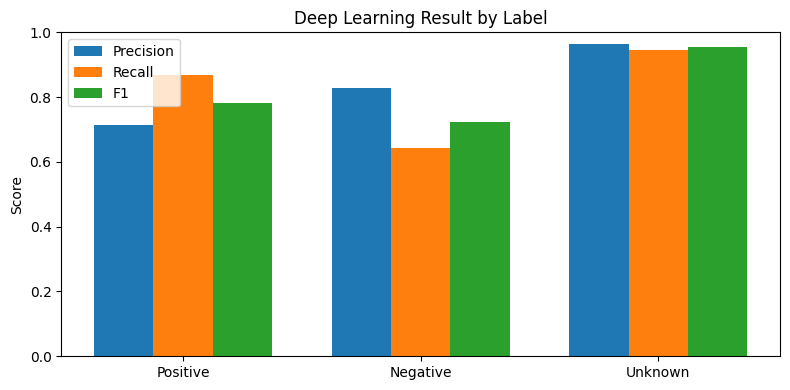

In [8]:
labels = [row[0] for row in per_label_rows]
precision = [float(row[1]) for row in per_label_rows]
recall = [float(row[2]) for row in per_label_rows]
f1 = [float(row[3]) for row in per_label_rows]

x = range(len(labels))
width = 0.25
plt.figure(figsize=(8, 4))
plt.bar([i - width for i in x], precision, width=width, label="Precision")
plt.bar(list(x), recall, width=width, label="Recall")
plt.bar([i + width for i in x], f1, width=width, label="F1")
plt.xticks(list(x), labels)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Deep Learning Result by Label")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Final Model Choice

Based on the comparison, **Deep Learning / DeBERTa** is the best model.

It achieves:

- Accuracy: **0.9197**
- Macro F1: **0.8205**
- Weighted F1: **0.9206**

This is good for the project because the model performs well overall and has much better macro F1 than the traditional ML model.

The limitation is that Negative labels are still harder because there are fewer Negative examples in the dataset.